- 1.2.2 계층으로 클래스화 및 순전파 구현
    - 신경망에서 하는 처리를 계층(layer)으로 구현, 완전연결계층에 의한 변환을 Affine 계층으로, 시그모이드 함수에 의한 변환을 Sigmoid 계층으로 구현, 완전연결계층에 의한 변환은 기하학에서의 아핀 변환에 해당하기 때문에 Affine 계층이라고 지정, 또한 각 계층은 파이썬 클래스로 구현, 기본 변환을 수행하는 메서드의 이름은 forward() 로 지정

- NOTE 심경망 추론 과정에서 하는 처리는 신경망의 순전파에 해당, 순전파란 말 그대로 입력층에서 출력층을 향하는 전파, 순전파 때는 신경망을 구성하는 각 계층이 입력으로부터 출력 방향으로 처리 결과를 차례로 전파, 후에 살펴볼 신경망 학습에서는 데이터(기울기)를 순전파와는 반대 방향으로 전파, 이를 역전파라 함

- 신경망에는 다양한 계층이 등장하는데, 이 계층들을 파이썬 클래스로 구현
    - 모든 계층은 forward()와 backword() 메서드를 가진다
    - 모든 계층은 인스턴스 변수인 params와 grads를 가진다.

- forward()와 backward() 메서드는 각각 순전파와 역전파를 수행, params는 가중치와 편향같은 매개변수를 담는 리스트(매개변수는 여러개가 있을 수 있기 때문에 리스트에 보관)
- 마지막으로 grads는 params에 저장된 각 매개변수에 대응하여ㅛ, 해당 매개변수의 기울기를 보관하는 리스트

- 일단 순전파 부터 구현, 앞의 구현 규칙 중 다음 두가지 적용
    - 1. 각 계층은 forward() 메서드만 가짐
    - 2. 매개변수들은 params 인스턴스 변수에 보관

In [1]:
import numpy as np

class Sigmoid:
    def __init__(self):
        self.params = []

    def forward(self, x):
        return 1 / (1 + np.exp(-x))

- 시그모이드 함수를 클래스로 구현, 주 변환 처리는 forward(x) 메서드가 담당, Sigmoid 계층에는 학습하는 매개변수가 따로 없기때문에 params는 빈 리스트로 초기화

In [2]:
class Affine:
    def __init__(self, W, b):
        self.params = [W, b]

    def forward(self, x):
        W, b = self.params
        out = np.matmul(x, W) + b
        return out

- Affine 계층은 초기화 될때 가중치와 편향을 받음, 즉 가중치와 편향은 Affine 계층의 매개변수(이 두 매개변수는 신경망이 학습될때 수시로 갱신), 리스트인 params 인스턴스 변수에 보관, forward(x)는 순전파 처리를 구현

- 구현해볼 신경망의 계층 구성

- X -> Affine -> Sigmoid -> Affine -> S
    - x 가 Affine 계층, Sigmoid 계층, Affine 계층을 거쳐 점수인 S를 출력

In [3]:
class TwoLayerNet:
    def __init__(self, input_size, hidden_size, output_size):
        I, H, O = input_size, hidden_size, output_size

        # 가중치와 편향 초기화
        W1 = np.random.randn(I, H)
        b1 = np.random.randn(H)
        W2 = np.random.randn(H, O)
        b2 = np.random.randn(O)

        # 계층 생성
        self.layers = [Affine(W1, b1), Sigmoid(), Affine(W2, b2)]

        # 모든 가중치를 리스트에 모음
        self.params = []

        for layer in self.layers:
            self.params += layer.params

    def predict(self, x):
        for layer in self.layers:
            x = layer.forward(x)
        
        return x

- 이 클래스의 초기화 매서드 (__init__)는 먼저 가중치를 초기화 하고 3개의 계층을 생성, 마지막으로 학습해야 할 가중치 매개변수들을 params 리스트에 저장
- 모든 계층은 자신의 학습 매개변수들을 인스턴스 변수인 params에 보관, 이 변수들을 더해주면 처리 완료.
- TwoLayerNet의 param 변수에는 모든 학습 매개변수가 담기게 됨

In [4]:
x = np.random.randn(10, 2)
model = TwoLayerNet(2, 4, 3)
s = model.predict(x)

s

array([[ 0.18367941, -0.61905378, -0.38429058],
       [-0.03889406, -0.30539946, -0.14929398],
       [ 0.12679151, -0.63722675, -0.34251714],
       [-0.21280841, -0.05530375,  0.18170318],
       [ 0.2399212 , -0.66828627, -0.13115446],
       [-0.22805369,  0.05888638, -0.04436497],
       [ 0.03486489, -0.41241518, -0.3657417 ],
       [ 0.11202242, -0.48438191, -0.17727767],
       [ 0.3097011 , -0.71121765,  0.20613024],
       [-0.25851581, -0.02117944, -0.01955757]])

- 1.3 신경망의 학습
    - 학습되지 않은 신경만은 좋은 추론을 해낼수 없음, 학습을 먼저 수행하고, 그 학습된 매개변수를 이용해 추론을 수행하는 흐름이 일반적
    - 추론이란 앞에서 본것과 같이 다중 클래스 분류등의 문제에 답을 구하는 작업
    - 신경만의 학습은 최적의 매개 변수 값을 찾는 작업

- 1.3.1 손실 함수
    - 신경망 학습에는 학습이 얼마나 잘 되고 있는 지를 알기 위한 척도가 필요, 일반적으로 학습 단계의 특정 시점에서 신경망의 성능을 나타내는 척도로 손실(loss)을 사용, 손실은 학습 데이터(학습시 주어진 정답 데이터)와 신경망이 예측한 결과를 비교하여 예측이 얼마나 나쁜가를 산출한 단일 값(스칼라)
    - 신경망의 손실은 손실함수(loss function)를 사용하 구함, 다중 클래스 분류 신경망에서는 손실함수는 흔히 교차 엔트로피 오차(Cross Entropy Error)를 이용, 교차 엔트로피 오차는 신경망이 출력하는 각 클래스의 확률과 정답 레이블을 이용해 구함
    - 우선 앞절의 신경망에 Softmax 계층과 Cross Entropy Error 계층 추가 (Softmax 계층은 소프트맥스 함수를 Cross Entropy Error 계층은 교차 엔트로피 오차를 구하는 계층)
    -                                    정답 레이블 t ↴
    - x -> Affine -> Sigmoid -> Affine -> Softmax -> Cross Entropy Error -> L
    - x는 입력 데이터, t는 정답 레이블, L은 손실을 나타냄, 이때 Softmax 계측의 출력은 확률이 되어, 다음 계층인 Cross Entropy Error 계층에는 확률과 정답 레이블이 입력
    - 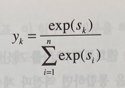 - 소프트 함수
    - 출력이 총 n개일때, k번째의 출력 y_k를 구하는 계산식
    - y_k는 k번째 클래스에 해당하는 소프트맥스 함수의 출력, 위 식에서 보듯 소프트맥스 함수의 분자는 점수 s_k의 지수 함수, 분모는 모든 입력 신호의 지수 함수의 총합
    - 소프트맥스 함수의 출력의 각 원소는 0.0이상 1.0 이하의 실수, 그리고 그 원소들을 모두 더하면 1.0
    - 이 부분이 소프트맥스의 출력을 확률로 해석할 수 있는 이유
    - 소프트맥스의 출력인 이 확률이 다음 차례인 교차 엔트로피 오차에 입력, 이때 교차 엔트로피 오차의 수식은 아래와 같은
    - 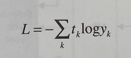
    - t_k는 k번째 클래스에 해당하는 정답 레이블, log는 네이피어 상수(혹은 오일러의 수) e를 밑으로 하는 로그, 정답 레이블은 t = [0, 0, 1] 과 같은 원핫 벡터로 표시
    

- NOTE 원핫 벡터란 단 하나의 원소만 1이고, 그외에는 0인 벡터, 여기서 1인 원소가 정답 클래스에 해당 따라서 교차 엔트로피 오차의 수식은 실질적으로 정답 레이블이 1의 원소에 해당하는 출력의 자연로그(log)를 계산할 뿐

- 미니배치 처리를 고려하면 교차 엔트로피 오차의 식은 아래와 같음, 아래 식에서 데이터는 N개 이며, t_n_k는 n번째 데이터의 k차원째의 값을 의미, 그리고 y_n_k는 신경망의 출력, t_n_k는 정답 레이블
- 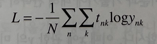
- 위 식은 하나의 데이터에 대한 손실 함수를 나타낸 식에서 데이터 N개로 확장
- 다만 위 식에서는 N으로 나누어서 1개당의 평균 손실 함수를 구함, 이렇게 평균을 구함으로써 미니배치의 크기에 관계없이 일관된 척도를 구할 수 있음
-                             정답 레이블 t ↴
- x -> Affine -> Sigmoid -> Affine -> Softmax with Loss -> L

- 1.3.2 미분과 기울기
    - 신경망 학습의 목표는 손실을 최소화하는 매개변수를 찾는 것, 이때 중요한 것은 미분과 기울기
    - 함수 y = f(x)가 있을 때 x에 관한 y의 미분은 dy/dx 로 표시, 이 dy/dx가 의미하는 것은 x의 값을 조금 변화시켰을때(이때 조금의 변화를 극한까지 줄일때) y의 값이 얼마나 변하는 가 하는 변화의 정도
    - y = x^2 이라는 함수를 예를 들면, 이 함수의 미분을 해석적으로 구하면 dy/dx = 2x가 됨
    - 이 미분 결과는 각 x에서의 변화의 정도를 뜻함, 아래 그림에서 보듯 함수의 기울기에 해당
    - 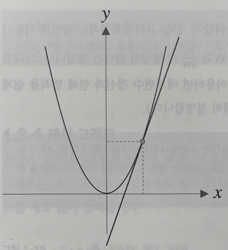
    - 위 그림에서는 x라는 변수 하나에 대해 미분을 구했지만, 여러개의 변수(다변수)라도 마찬가지로 미분 가능, 
    - 예를 들어 L은 스칼라, x는 벡터인 함수 L = f(x)가 있을때 (x의 i번째 원소인) x_i에 대한 L의 미분은 $\frac{\partial L}{\partial x_i}$ 로 쓸수 있음
    - 그리고 벡터 x의 다른 원소의 미분도 구할 수 있고, 이를 아래와 같이 정리
    - 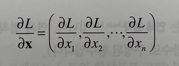
    - 이처럼 벡터의 각 원소에 대한 미분을 정리한 것이 기울기
    - 벡터와 마찬가지로, 행렬에서도 기울기를 생각 할 수 있음, 예를 들어 W가 m * n 행렬이라면 L = g(w) 함수의 기울기는 아래와 같이 쓸수 있음
    - 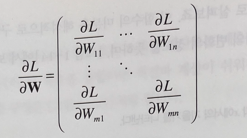
    - 위 식 처럼 L의 W에 대한 기울기를 행렬로 정기 가능, 여기에서 중요한 점은 W와 $\frac{\partial L}{\partial W}$ 의 형상이 같는 것, 그리고 행렬과 그 기울기의 형상이 같다 라는 이 성질을 이용하면 매개변수 갱신과 연쇄 법칙을 쉽게 구현 가능


- 1.3.3 연쇄 법칙
    - 학습 시 신경망은 학습 데이터를 주면 손실을 출력, 여기서 얻고 싶은 것은 각 매개변수에 대한 손실의 기울기, 그 기울기를 얻을 수 있다면, 그것을 사용해 매개변수를 갱신 가능, 신경망의 기울기는 오차역전파법으로 구할 수 있음
    - 오차역전파법을 이해하는 열쇠는 연쇄법칙, 연쇄법칙이란 합성함수에 대한 미분의 법칙
    - 연쇄 법칙, 예를 들어 y = f(z)와 z = g(y)라는 두 함수가 있을 때 z = g(f(x))가 되어, 최종 출력 z는 두 함수를 조합해 계산 가능, 이때 이 합성함수의 미분(x에 대한 z의 미분)은 아래와 같이 구할 수 있음
    - $\frac{\partial z}{\partial x}$ = $\frac{\partial z}{\partial y}$·$\frac{\partial y}{\partial x}$
    - 위 식에서와 같이 x에 대한 z의 미분은 y = f(x)의 미분과 z = g(y)의 미분을 곱하면 구해짐, 이것이 바로 연쇄 법칙
    - 연쇄 법칙이 중요한 이유는 우리가 다루는 함수가 아무리 복잡하다 하더라고, 즉 아무리 많은 함수를 연결하더라도, 그 미분은 개별 함수의 미불들을 이용해 구할수 있기 때문, 달리 말하면 국소적인 미분을 계산할 수 있다면 그 값들을 곱해서 전체의 미분을 구할 수 있음

    - NOTE 신경만은 여러 함수가 연결된 것이라고 생각할 수 있음, 오처역전파법은 그 여러함수(신경망)에 대해 연쇄 법칙을 효율적으로 적용하여 기울기를 구해냄

- 1.3.4 계산 그래프
    - 계산 그래프는 계산 과정을 시각적으로 보여줌
    - 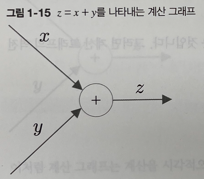
    - 위 그림에서 보듯 계산 그패프는 노드와 화살표로 그림, 더하기를 +노드로 나타내고, 변수 x와 y를 해당 화살표 위에 씀
    - 이처럼 계산 그래프에서는 연산을 노드로 나타내고 그 처리 결과가 순서대로 흐름
    - 이것이 계산 그래프의 순전파
    - 계산 그래프를 이용하면 계산을 시각적으로 파악 가능, 게다가 그 기울기도 직관적으로 구할 수 있음, 여기서 중요한 점은 기울기가 순전파와 반대 방행으로 전파, 이 반대 방향의 전파가 역전파

- 역전파를 설명 하기에 앞서 역전파가 이루어지는 전체 그림 체크
- z = x + y 라는 계산을 다루는 중 아래 그림과 같이 이 계산 앞뒤로도 어떤 계산이 있다고 가정
- 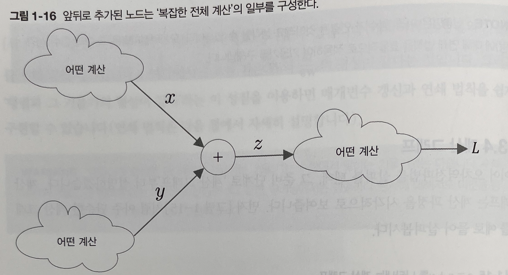
- 그림에서와 같이 최종적으로 스칼라 값인 L이 출력 (신경망 학습에서 계산 그래프의 최종 출력은 손실이며 그 값은 스칼라)
- 목표는 L의 미분(기울기)을 각 변수에 대하 구하는 것, 그러면 계산 그래프의 역전파는 아래 그림과 같음
- 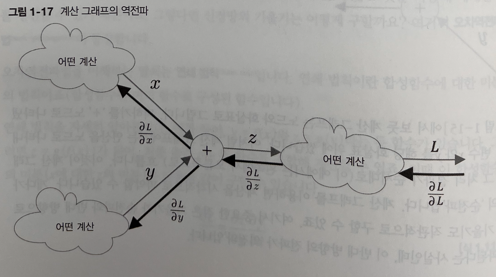
- 위 그림에서 처럼 역전파는 두꺼운 화살표로 그리고, 화살표 아래에 전파되는 값을 쓰고, 이때 전파되는 값은 최종 출력 L의 각 변수에 대한 미분, 이 예에서는 z에 대한 미분은 $\frac{\partial L}{\partial z}$ 이고, x와 y에 대한 미분은 각각 $\frac{\partial L}{\partial x}$ 과 $\frac{\partial L}{\partial y}$ 
- 그리고 여기서 다시 연쇄 법칙이 등장, 앞서 복습한 연쇄 법칙에 따르면 역전파로 흐르는 미분 값은 상류로뷰터 흘러온 미분과 각 연산 노드의 국소적인 미분을 곱해 계산할 수 있음(여기서 상류는 출력 쪽을 가르킴) 그러므로 이 예에서는 $\frac{\partial L}{\partial x}$ = $\frac{\partial L}{\partial z}$·$\frac{\partial z}{\partial x}$ 이고, $\frac{\partial L}{\partial y}$ = $\frac{\partial L}{\partial z}$·$\frac{\partial z}{\partial y}$ 가 됩니다.
- 여기서 지금 z = x + y 의 덧셈 노드에서 이루어지는 연산을 다룰 때, $\frac{\partial z}{\partial x}$ = 1 과 $\frac{\partial z}{\partial y}$ = 1 이라는 결과를 구할 수 있음, 이 결과를 적용하면 덧셈 노드는 아래 그림 처럼 상류로 부터 받은 값에 1을 곱하여 하류로 기울기를 전파, 즉 상류호부터의 기울기를 그래도 흘리기만 함
- 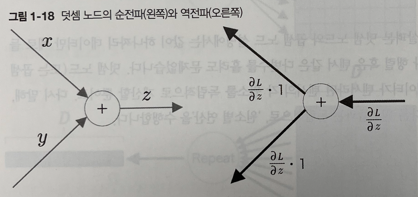
- 이처럼 계산 그래프는 계산을 시각적으로 보여줌, 그리고 역전파에 의한 기울기 흐름을 살펴봄으로써, 그 도출 과정을 이해하는데 도움을 줌

- 곱셈 노드
    - 곱셈 노드는 z = x * y 계산을 수행, 이때 $\frac{\partial z}{\partial x}$ = y 와 $\frac{\partial z}{\partial y}$ = x 라는 미분 결과를 각각 구할 수 있음
    - 따라서 곱셈 노드의 역전파는 아래 그림 처럼 상류로부터 받은 기울기에 순전파시의 입력을 서로 바꾼 값을 곱함(즉 순전파 시 입력이 x면 y를 곱하고, y면 x를 곱함)
    - 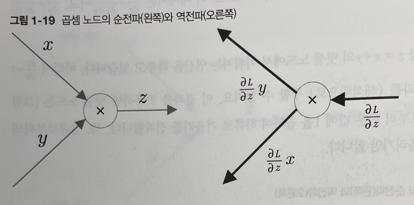
    - 참고로, 지금까지 살펴본 덧셈 노드와 곱셈 노드 설명에서는 값이 하나짜리 데이터만 예로 들었지만, 벡터나 행렬 혹은 텐서 같은 다변수를 흘려도 문제 없음, 덧셈 노드 (or 곱셈 노드)를 흐르는 데이터가 텐서라면 텐서의 각 원소를 독립적으로 계산하는 것, 이 경우는 텐서의 다른 원소들과는 독립적으로 원소별 연산을 수행

- 분기 노드
    - 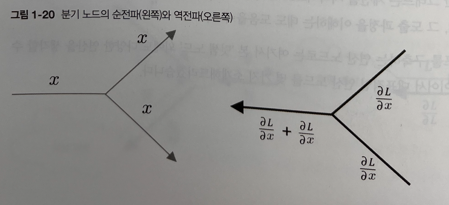
    - 분기 노드는 따로 그리지 않고 단순히 선이 두개로 나뉘도록 그리는 데 이때 같은 값이 복제되어 분기
    - 따라서 분기 노드를 복제 노드라고 할 수도 있음
    - 그리고 그 역전파는 위 그림에서 보듯 상류에서 온 기울기들의 합 이 됨

- Repeat 노드
    - 2개로 분기하는 분기 노드를 일반화 하면 N개로의 분기가 진행, 이를 Repeat 노드라고 함
    - 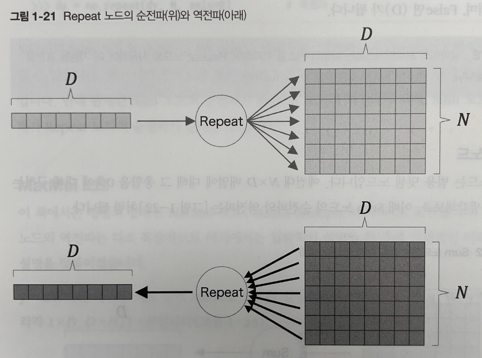
    - 위 그림은 길이가 D인 배열을 N개로 복제하는 예, 이 Repeat 노드는 N개의 분기 노드로 볼 수 있음
    - 그 역전하는 N개의 기울기를 모두 더해 구할 수 있음

In [5]:
import numpy as np

D, N = 8, 7
x = np.random.randn(1, D)               # 입력
y = np.repeat(x, N, axis=0)             # 순전파
dy = np.random.randn(N, D)              # 무작위 기울기
dx = np.sum(dy, axis=0, keepdims=True)  # 역전파

dx

array([[ 1.06357578, -3.44636379, -0.41528526,  2.40203122, -2.52220663,
         4.01086284,  3.30956848, -1.81878412]])

- 여기서는 np.repeat() 메서드가 우너소 복제를 수행, 이 코드에서는 배열 x를 N번 복제하는데, 이때 axis를 지정하여 어느 축 방향으로 복제할지를 조정 가능
- 또 역전파에서는 총합을 구해야 하므로 np.sum() 메서드를 이용, 이때도 axis 인수를 설정하여 어느축 방향으로 합을 구할지 지정, 또한 인수로 keepdims=True를 설정하여 2차원 배열의 차원 수를 유지, 이 예에서는 keepdims가 True면 np.sum()의 결과릐 형상은 (1, D)가 되며, False면 (D)가 됨
- NOTE 넘파이의 브로드캐스트는 배열의 원소를 복제하며, Repeat 를 사용하여 이 기능을 표현

- Sum 노드
    - Sum 노드는 범용 덧셈 노드, 예컨데 N x D 배열에 대해 그 총합을 0축에 대하 구하는 계산이라면, 이때 Sum 노드의 순전파와 역적파는 아래와 같음
    - 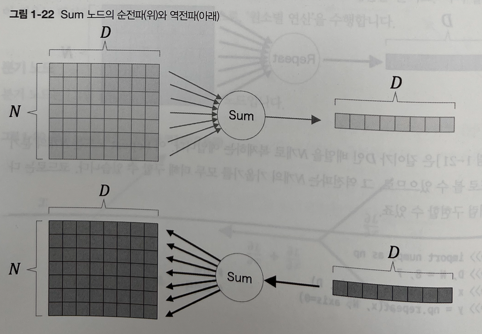
    - 위 그림에서 보든, Sum 노드의 역전파는 상류로부터의 기울기를 모든 화살표에 분배, 덧셈 노드의 역전파를 자연스럽게 확장한 것

In [6]:
import numpy as np
D, N = 8, 7
x = np.random.randn(N, D)               # 입력
y = np.sum(x, axis=0, keepdims=True)    # 순전파

dy = np.random.randn(1, D)              # 무작위 기울기
dx = np.repeat(dy, N, axis=1)           # 역전파

dx

array([[-1.79835898, -1.79835898, -1.79835898, -1.79835898, -1.79835898,
        -1.79835898, -1.79835898, -0.7364639 , -0.7364639 , -0.7364639 ,
        -0.7364639 , -0.7364639 , -0.7364639 , -0.7364639 ,  1.79900955,
         1.79900955,  1.79900955,  1.79900955,  1.79900955,  1.79900955,
         1.79900955, -1.77262044, -1.77262044, -1.77262044, -1.77262044,
        -1.77262044, -1.77262044, -1.77262044,  1.99898809,  1.99898809,
         1.99898809,  1.99898809,  1.99898809,  1.99898809,  1.99898809,
        -1.46547379, -1.46547379, -1.46547379, -1.46547379, -1.46547379,
        -1.46547379, -1.46547379, -0.51639129, -0.51639129, -0.51639129,
        -0.51639129, -0.51639129, -0.51639129, -0.51639129,  0.41043978,
         0.41043978,  0.41043978,  0.41043978,  0.41043978,  0.41043978,
         0.41043978]])

- 위 코드와 같이 Sum 노드의 순전파는 np.sum() 메서드로, 역전파는 np.repeat() 메서드로 구현 할 수 있음
- Sum 노드와 Repeat 노드는 서로 반대 관계
- 반대 관계란 Sum 노드의 순전파가 Repear 노드의 역전파가 되며, Sum 노드의 역전파가 Repeat 노드의 순전파가 됨

- MatMul 노드
    - 행렬의 곱생을 MatMul 노드로 표현 할때 (Matrix Multiply의 약자), MatMul 노드의 역전파는 다소 복잡
    - y = xW 라는 계산을 예로 들면 아래 그림과 같이 x, W, y의 형상은 각각 1 x D, D x H, 1 x H
    - 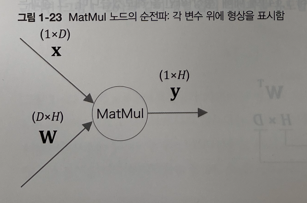
    - 이 때 x의 i번째 원소에 대한 미분 $\frac{\partial L}{\partial x_i}$ 아래와 같이 구함
    - 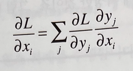
    - 이 식의 $\frac{\partial L}{\partial x_i}$ 은 x_i를 (조금) 변화시켰을 때 L이 얼마나 변할 것인가라는 변화의 정도를 나타냄
    - 여기서 x_i를 변화시키면 벡터 y의 모든 원소가 변하고 그로 인해 최종적으로 L이 변하게 됨
    - 따라서 x_i에서 L에 이르는 연쇄 법칙의 경로는 여러개가 있으며 그 총합은 $\frac{\partial L}{\partial x_i}$ 이 됨
    - 위 식을 보면 $\frac{\partial y_i}{\partial x_i}$ = W_i_j 가 성립하므로 이를 위 식에 대입하면 아래와 같이 됨
    - 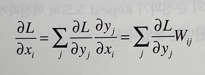
    - 위 식에서 $\frac{\partial L}{\partial x_i}$ 은 벡터 $\frac{\partial L}{\partial y}$ 과 W의 i행 벡터의 내적으로 구해짐을 알 수 있음, 그렇다면 이 관계로부터 아래 식을 유도 할 수 있음
    - 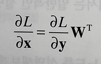
    - 위 식에서 알 수 있듯이 $\frac{\partial L}{\partial x}$ 은 행렬의 곱을 사용해 구할 수 있음
    - 여기서 W^T의 T는 전치행렬, 아래 그림은 위 그림에 대한 형상 확인
    - 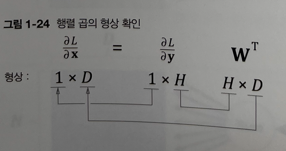
    - 위 그림에서 행렬의 형상이 올바름을 알 수 있음, 따라서 
    - 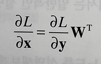
    - 위 식이 올바른 계산임을 확인 가능, 또 이를 역으로 취해(그 적합성이 성립되게 함으로써), 역전파의 수식(구현)을 유도할 수도 있는데 이 방법도 y = xW라는 행렬 곱 계산을 예로 설명, 이번에는 미니배치 처리를 고려해 x에는 N개의 데이터가 담겨 있다고 가정
    - 그러면 x, W, y의 형상은 각각 N x D, D x H, N x H 가 되어, 역전파의 그래프는 아래 처럼 됨
    - 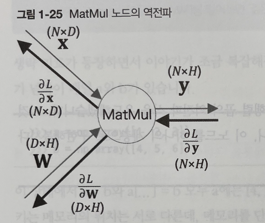
    - 이제 $\frac{\partial L}{\partial x}$ 의 계산은 , $\frac{\partial L}{\partial x}$ 과 관련된 변수(행렬)는 상류에서의 기울기 $\frac{\partial L}{\partial y}$ 과 W, 여기에서 W가 관여되는 이유는 곱셈의 역전파와 관련, 곱셈의 역전파에서는 순전파 시의 입력을 서로 바꾼 값을 사용, 이와 마찬가지로 행렬의 역전파에서도 순전파 시의 입력을 서로 바꾼 행렬을 사용,
    - 아래 그림과 같이 행렬 곱의 역전파를 유도
    - 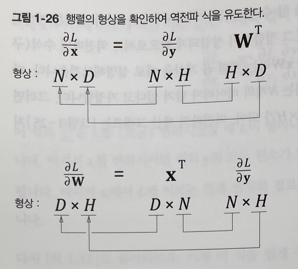
    - 위 그림과 같이 행렬의 형상을 확인 하여 행렬 곱의 역전파 식을 유도

In [7]:
class MatMul:
    def __init__(self, W):
        self.params = [W]
        self.grads = [np.zeros_like(W)]
        self.x = None

    def forward(self, x):
        W, = self.params
        out = np.matmul(x, W)
        self.x = x

        return out
    
    def backward(self, dout):
        W, = self.params
        dx = np.matmul(dout, W.T)
        dW = np.matmul(self.x.T, dout)
        self.grads[0][...] = dW

        return dx

- MatMul 계층은 학습하는 매개변수를 params에 보관, 그리고 거기에 대응시키는 형태로 기울기는 grads에 보관
- 역전파에서는 dx와 dW를 구해 가중치의 기울기를 인스턴스 변수인 grads에 저장
- self.grads[0][...]  = dW 코드에서 점 3개로 이루어진 생략 기호 사용, 이렇게 하면 넘파이 배열이 가리키는 메모리 위치를 고정 시킨 다음 그 위치에 원소들을 덮어씀
    - grads[0] = dW 처럼 할당해도 되지만 생략 기호는 넘파이 배열의 덮어쓰기를 수행, 결국 얕은 복사냐 깊은 복사냐의 차이, grads[0] = dW 처럼 그냥 할당하면 얕은 복사가 되고, grads[0][...] = dW 처럼 엎어쓰면 깊은 복사가 됨

- 생략 기호에 대한 구체적인 예 아래 코드에서 진행

In [8]:
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

- 위 상태에서 a = b 와 a[...] = b 모두 a에 [4, 5, 6]이 할당 됨, 그러나 두 경우에 a가 가리키는 메모리의 위치는 서로 다름
- 메모리를 단순화 해 시각화 하면 아래 그림 처럼 됨
- 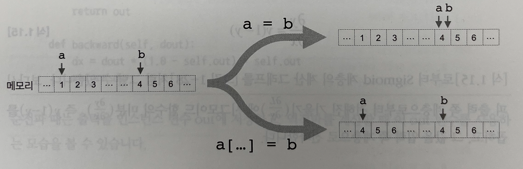
- 위 그림 처럼 a = b 에서는 a가 가리키는 메모리 위치가 b가 가리키는 위치와 같아짐
- 실제 데이터 (4, 5, 6)는 복제되지 않는 다는 뜻으로 얕은 복사
- 한편 a[...] = b 일때 a의 메모리 위치는 변하지 않고 대신 a가 가리키는 메모리에 b의 원소가 복제됨, 이 경우는 깊은 복사
- 이상 생략 기호를 이용하여 변수의 메모리 주소를 고정할 수 있음을 알아봄
- grads 리스트에는 각 매개변수의 기울기를 저장, 이때 grads 리스트의 각 원소는 넘파이 배열, 계층을 생성할 때 한번 만 생성
- 그 후로는 항상 생략 기호를 이용, 이 넘파이 배열의 메모리 주소가 변하는 일 없이 항상 값을 덮어씀, 이렇게 하면 기울기를 그룹화하는 작업을 최초에 한 번만 하면 된다는 이점이 생김

- 1.3.5 기울기 도출과 역전파 구현
    - 계산 그래프 설명도 끝났으니 Sigmoid 계층 완전연결계층의 Affine 계층, Sofrmax with Loss 계층 구현 진행

- Sigmoid 계층
    - 시그모이드 함수를 수식으로 쓰면 y = 1 / 1 + exp(-x), 그리고 미분은 아래와 같음
    - $\frac{\partial y}{\partial x}$ = y(1 - y)
    - 위 식으로부터 Sigmoid 계층의 계산 그래프를 아래 그림처럼 그릴 수 있음
    - 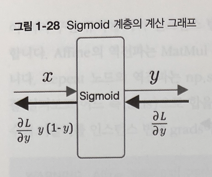
    - 위 그림은 출력 쪽 계층으로부터 전해진 기울기 ($\frac{\partial L}{\partial y}$) 에 시그모이드 함수의 미분 ($\frac{\partial y}{\partial x}$), 즉 y(1 - y)를 곱하고 그 값을 입력쪽 계층으로 전파

In [9]:
class Sigmoid:
    def __init__(self):
        self.params, self.grads = [], []
        self.out = None

    def forward(self, x):
        out = 1 / (1 + np.exp(-x))
        self.out = out
        return out
    
    def backward(self, dout):
        dx = dout * (1.0 - self.out) * self.out
        return dx

- 순전파 때는 출력을 인스턴스 변수 out에 저장하고, 역전파를 계산할때 이 out 변수를 사용

- Affine 계층
    - Affine 계층의 순전파는 y = np.matmul(x, W) + b 로 구현 가능
    - 여기서 편향을 더할 때는 넘파이의 브로드캐스트가 사용, Affine 계층의 계산 그래프는 아래 그림처럼 그릴 수 있음
    - 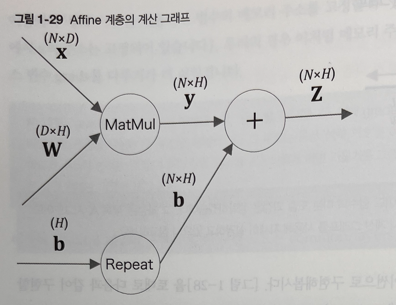
    - 위 그림처럼 MatMul 노드로 행렬 곱을 계산, 그리고 편향은 Repeat 노드에 의해 복제된 후 더해짐

In [10]:
class Affine:
    def __init__(self, W, b):
        self.params = [W, b]
        self.grads = [np.zeros_like(W), np.zeros_like(b)]
        self.x = None

    def forward(self, x):
        W, b = self.params
        out = np.matmul(x, W) + b
        self.x = x

        return out
    
    def backward(self, dout):
        W, b = self.params
        dx = np.matmul(dout, W.T)
        dW = np.matmul(self.x.T, dout)
        db = np.sum(dout, axis=0)

        self.grads[0][...] = dW
        self.grads[1][...] = db

        return dx

- 인스턴스 변수 params에는 매개변수를, grads에는 기울기를 저장
- Affine의 역전파는 MatMul 노드와 Rrpeat 노드의 역전파를 수행하면 구할 수 있음
- Repear 노드의 역전파는 np.sum() 메서드로 계산 가능, 이때 행렬의 형상을 잘 살펴보고 어느축(axis)으로 합을 구할지를 명시
- 마지막으로 가중치 매개변수의 기울기를 인스턴스 변수 grads에 저장

- Softmax with Loss 계층
    - 소프트맥스 함수와 교차 엔트로피 오차는 Softmax with Loss라는 하나의 계층으로 구현
    - 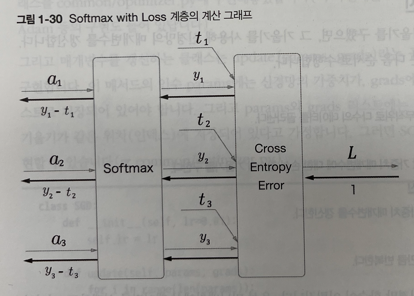
    - 위 계산 그래프에서는 소프트 맥스 함수는 Sofrmax 계층으로, 교차 엔트로피 오차는 Cross Entropy Error 계층으로 표기
    - 그리고 3-클래스 분류를 가정 하여 이전 계층(입력층에 가까운 계층)으로 부터 3개의 입력을 받도록 함
    - 위 그림 처럼 Softmax 계층은 입력이 (a_1, a_2, a_3)를 정규화 하여 (y_1, y_2, y_3)를 출력
    - 그리고 Cross Entropy Error 계층은 Softmax의 출력 (y_1, y_2, y_3)와 정답 레이블 (t_1, t_2, t_3)를 받고 이 데이터로부터 손실 L을 구해 출력
    - NOTE 위 그림에서 주목할 부분은 역전파의 결과, Softmax 계층의 역전파는 (y_1 - t_1, y_2 - t_2, y_3 - t_3) 로 정리
    - (y_1, y_2, y_3)는 Softmax 계층의 출력, (t_1, t_2, t_3)는 정답 레이블이므로 Softmax 계층의 역전파는 자신의 출력과 정답 레이블의 차이, 이처럼 신경망의 역전파응 이 차이(오차)를 앞 계층에 전해주는 것으로 신경망 학습에서 중요한 성질

- 가중치 갱신
    - 오차역전파법으로 기울기를 구했으면, 그 기울기를 사용해 신경망의 매개변수를 갱신
    - 이 때 신경망의 핛브은 다음 순서로 수행
        - 1단계: 미니배치
            - 훈련 데이터 중에서 무작위로 다수의 데이터를 골라냄
        - 2단계: 기울기 계산
            - 오차역전파법으로 각 가중치 매개변수에 대한 손실 함수의 기울기를 구함
        - 3단계: 매개변수 갱신
            - 기울기를 사용하여 가중치 매개변수를 갱신
        - 4단계: 반복
            - 1 ~ 3 단계를 필요한 만큼 반복
    - 이러한 단계를 거쳐 신경망 학습이 진행, 우선 미니배치에서 데이터를 선택하고 이어서 오차역전차법으로 가중치의 기울기를 구함
    - 이 기울기는 현재의 가중치 매개변수에서 손실을 가장 크게 하는 방향을 가리킴, 따라사 매개변수를 그 기울기와 반대 방향으로 갱신하면 손실을 줄일 수 있음
    - 이것이 바로 경사하강법(Gradient Descent)
    - 3단계에서 수행하는 가중치 갱신 기법의 종류는 아주 다양한데, 여기에서는 그중 가장 단순한 확률적 경사하강법(SGD)을 구현
    - 확률적은 무작위로 선택된 데이터(미니배치)에 대한 기울기를 이용한다는 뜻
    - SGD는 단순한 방버브 SGD는 (현재의) 가중치를 기울기 방향으로 일정한 거리만큼 갱신
    - 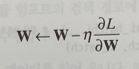
    - 위 식에서 갱신하는 가중치 매개변수가 w이고 W에 대한 손실 함수의 기울기가 $\frac{\partial L}{\partial W}$
    - $\eta$ 는 학습률(learning rate)을 나타냄, 0.01이나 0.001 같은 값을 미지 정해 사용

In [11]:
class SGD:
    def __init__(self, lr=0.01):
        self.lr = lr

    def update(self, params, grads):
        for i in range(len(params)):
            params[i] -= self.lr * grads[i]

- 매개변수를 갱신하는 클래스는 update(params, grads)라는 공통 메서드를 갖도록 구현
- 이 메서드의 인수 params에는 신경망의 가중치가, grads에는 기울기가 각각 리스트로 저장되어야 함
- 그리고 params와 grads 리스트에는 대응 하는 매개변수와 기울기가 같은 위치(인덱스)에 저장되어 있다고 가정
- 초기화 인수 lr은 학습률을 뜻하며, 그 값을 인스턴스 변수로 저장
- update(params, grads) 메서드는 매개변수 갱신을 처리

- 1.4 신경망으로 문제를 풀다
    - 신경망 학습 진행

x (300, 2)
t (300, 3)


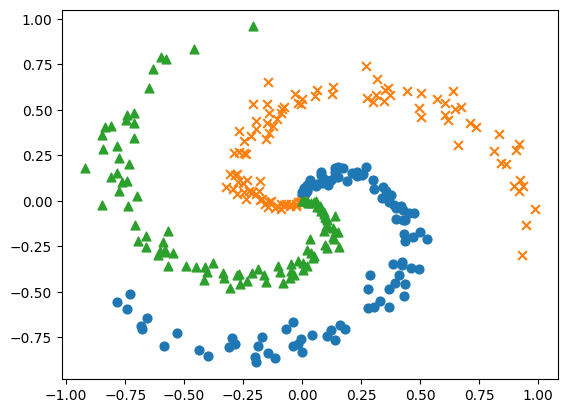

In [1]:
import sys
sys.path.append("dataset/")

from dataset import spiral
import matplotlib.pyplot as plt

x, t = spiral.load_data()
print("x", x.shape)
print("t", t.shape)

N = 100
CLS_NUM = 3
markers = ["o", "x", "^"]
for i in range(CLS_NUM):
    plt.scatter(x[i * N: (i + 1) * N, 0], x[i * N: (i + 1) * N, 1], s=40, marker=markers[i])

plt.show()

- 위 그림 처럼 입력은 2차원 데이터 분류할 클래스 수는 3개 이 그래프를 부면 직선만으로는 클래스들을 분리 할 수 없음
- 따라서 비선형 분리를 학습해야 함(비선형인 시그모이드 함수를 활성화 함수로 사용하는 은닉층이 있는 형태)

In [3]:
import sys
sys.path.append("..")

import numpy as np
from common.layers import Affine, Sigmoid, SoftmaxWithLoss

class TwoLayerNet:
    def __init__(self, input_size, hidden_size, outout_size):
        I, H, O = input_size, hidden_size, outout_size

        # 가중치와 편향 초기화
        W1 = 0.01 * np.random.randn(I, H)
        b1 = np.zeros(H)
        W2 = 0.01 * np.random.randn(H, O)
        b2 = np.zeros(O)

        # 계층 생성
        self.layers = [
            Affine(W1, b1),
            Sigmoid(),
            Affine(W2, b2)
        ]
        self.loss_layer = SoftmaxWithLoss()

        # 모든 가중치와 기울기를 리스트에 모음
        self.params, self.grads = [], []
        for layer in self.layers:
            self.params += layer.params
            self.grads += layer.grads

    def predict(self, x):
        for layer in self.layers:
            x = layer.forward(x)
        return x
    
    def forward(self, x, t):
        scere = self.predict(x)
        loss = self.loss_layer.forward(scere, t)
        return loss
    
    def backward(self, dout=1):
        dout = self.loss_layer.backward(dout)
        for layer in reversed(self.layers):
            dout = layer.backward(dout)
        return dout


- 초기화 메서드는 3개의 인수를 받는데 차례대로 input_size는 입력층의 뉴런 수, hidden_size는 은닉층의 뉴런 수, outout_size 는 출력층의 뉴런 수
- 메서드 안에서는 우선 편향을 영벡터로 초기화 하고(np.zeros()), 가중치는 작은 무작위 값으로 초기화(0.01 * np.random.randn())
- 가중치의 경우 무작위 값으로 설정하면 학습이 더 잘 진행될 가능성이 커짐
- 필요한 계층을 생성해 인스턴스 변수인 layers 리스트에 모우두고 마지막으로 이 모델에서 사용하는 매개변수들과 기울기 들을 각각 하나로 모음
- Softmax with Loss 계층은 다른 계층과 다르게 취급하여 layers 리스트가 아닌 loss_layer 인스턴스 변수에 별도로 저장

| 에폭 1 | 반복 10 / 10 | 손실 1.13
| 에폭 2 | 반복 10 / 10 | 손실 1.13
| 에폭 3 | 반복 10 / 10 | 손실 1.12
| 에폭 4 | 반복 10 / 10 | 손실 1.12
| 에폭 5 | 반복 10 / 10 | 손실 1.11
| 에폭 6 | 반복 10 / 10 | 손실 1.14
| 에폭 7 | 반복 10 / 10 | 손실 1.16
| 에폭 8 | 반복 10 / 10 | 손실 1.11
| 에폭 9 | 반복 10 / 10 | 손실 1.12
| 에폭 10 | 반복 10 / 10 | 손실 1.13
| 에폭 11 | 반복 10 / 10 | 손실 1.12
| 에폭 12 | 반복 10 / 10 | 손실 1.11
| 에폭 13 | 반복 10 / 10 | 손실 1.09
| 에폭 14 | 반복 10 / 10 | 손실 1.08
| 에폭 15 | 반복 10 / 10 | 손실 1.04
| 에폭 16 | 반복 10 / 10 | 손실 1.03
| 에폭 17 | 반복 10 / 10 | 손실 0.96
| 에폭 18 | 반복 10 / 10 | 손실 0.92
| 에폭 19 | 반복 10 / 10 | 손실 0.92
| 에폭 20 | 반복 10 / 10 | 손실 0.87
| 에폭 21 | 반복 10 / 10 | 손실 0.85
| 에폭 22 | 반복 10 / 10 | 손실 0.82
| 에폭 23 | 반복 10 / 10 | 손실 0.79
| 에폭 24 | 반복 10 / 10 | 손실 0.78
| 에폭 25 | 반복 10 / 10 | 손실 0.82
| 에폭 26 | 반복 10 / 10 | 손실 0.78
| 에폭 27 | 반복 10 / 10 | 손실 0.76
| 에폭 28 | 반복 10 / 10 | 손실 0.76
| 에폭 29 | 반복 10 / 10 | 손실 0.78
| 에폭 30 | 반복 10 / 10 | 손실 0.75
| 에폭 31 | 반복 10 / 10 | 손실 0.78
| 에폭 32 | 반복 10 / 10 | 손실 0.77
| 에폭 33 | 반복 10 /

/home/sado/miniconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/sado/miniconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48373 (\N{HANGUL SYLLABLE BOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/sado/miniconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49552 (\N{HANGUL SYLLABLE SON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/sado/miniconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


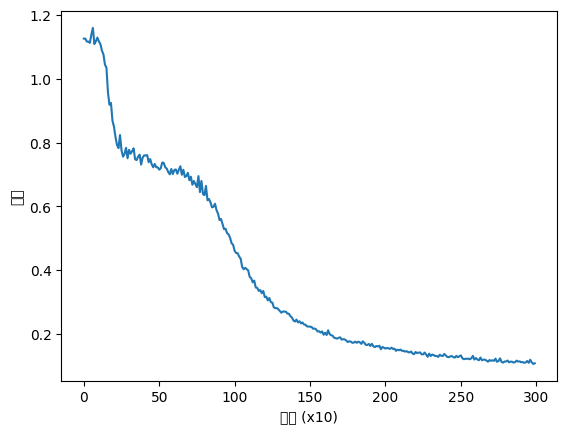

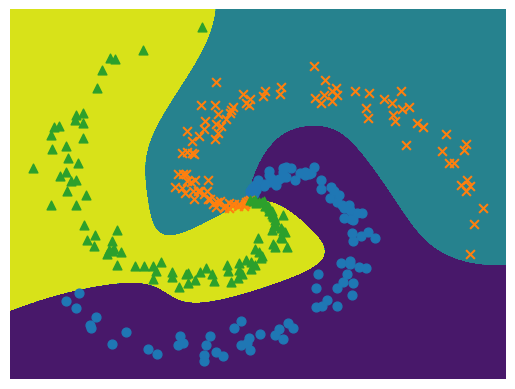

In [8]:
import sys
sys.path.append("..")
import numpy as np
from common.optimizer import SGD
from dataset import spiral
import matplotlib.pylab as plt
from two_layers_net import TwoLayerNet

# 1. 하이퍼파라미터 설정
max_epoch = 300
batch_size = 30
hidden_size = 10
learning_rate = 1.0

# 2. 데이터읽기, 모델과 옵티마이저 생성
x, t = spiral.load_data()
model = TwoLayerNet(input_size=2, hidden_size=hidden_size, outout_size=3)
optimizer = SGD(lr=learning_rate)

# 학습에 사용하는 변수
data_size = len(x)
max_iters = data_size // batch_size
total_loss = 0
loss_count = 0
loss_list = []

for epoch in range(max_epoch):
    # 3. 데이터 뒤섞기
    idx = np.random.permutation(data_size)
    x = x[idx]
    t = t[idx]

    for iters in range(max_iters):
        batch_x = x[iters * batch_size:(iters + 1) * batch_size]
        batch_t = t[iters * batch_size:(iters + 1) * batch_size]

        # 4. 기울기를 구해 매개변수 갱신
        loss = model.forward(batch_x, batch_t)
        model.backward()
        optimizer.update(model.params, model.grads)

        total_loss += loss
        loss_count += 1

        # 5. 정기적으로 학습 결과 출력
        if (iters + 1) % 10 == 0:
            avg_loss = total_loss / loss_count
            print("| 에폭 %d | 반복 %d / %d | 손실 %.2f" % (epoch + 1, iters + 1, max_iters, avg_loss))
            loss_list.append(avg_loss)
            total_loss, loss_count = 0, 0

# 학습 결과 플롯
plt.plot(np.arange(len(loss_list)), loss_list, label='train')
plt.xlabel('반복 (x10)')
plt.ylabel('손실')
plt.show()

# 경계 영역 플롯
h = 0.001
x_min, x_max = x[:, 0].min() - .1, x[:, 0].max() + .1
y_min, y_max = x[:, 1].min() - .1, x[:, 1].max() + .1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
X = np.c_[xx.ravel(), yy.ravel()]
score = model.predict(X)
predict_cls = np.argmax(score, axis=1)
Z = predict_cls.reshape(xx.shape)
plt.contourf(xx, yy, Z)
plt.axis('off')

# 데이터점 플롯
x, t = spiral.load_data()
N = 100
CLS_NUM = 3
markers = ['o', 'x', '^']
for i in range(CLS_NUM):
    plt.scatter(x[i*N:(i+1)*N, 0], x[i*N:(i+1)*N, 1], s=40, marker=markers[i])
plt.show()


- 1. 우선 하이퍼파라미터를 설정, 구체적으로는 학습하는 에폭 수, 미니배치 크기, 은닉층의 뉴런 수, 학습률을 설정
- 2. 계속해서 데이터를 읽고, 신경망(모델)과 옵티마이저를 생성
- NOTE 에폭(epoch)은 학습 단위, 1에폭은 학습 데이터를 모두 살펴본 시점(데이터셋을 1바튀 돌아본 시점)
- 학습은 미니배치 방식으로 진행되며 데이터는 무작위로 선택
- 3. 여기서는 에폭 단위로 데이터를 섞고, 섞은 데이터중 앞에서부터 차례대로 진행 하는 방식 사용
- 4. 계속해서 기눌기를 구해 매개변수를 갱신
- 5. 마지막으로 정기적으로 학습 결과를 출력
    - 학습 결과를 보면 손실값이 순조롭게 낮아짐(그래프 확인)

| 에폭 1 |  반복 1 / 10 | 시간 0[s] | 손실 1.10
| 에폭 2 |  반복 1 / 10 | 시간 0[s] | 손실 1.12
| 에폭 3 |  반복 1 / 10 | 시간 0[s] | 손실 1.13
| 에폭 4 |  반복 1 / 10 | 시간 0[s] | 손실 1.12
| 에폭 5 |  반복 1 / 10 | 시간 0[s] | 손실 1.12
| 에폭 6 |  반복 1 / 10 | 시간 0[s] | 손실 1.10
| 에폭 7 |  반복 1 / 10 | 시간 0[s] | 손실 1.14
| 에폭 8 |  반복 1 / 10 | 시간 0[s] | 손실 1.16
| 에폭 9 |  반복 1 / 10 | 시간 0[s] | 손실 1.11
| 에폭 10 |  반복 1 / 10 | 시간 0[s] | 손실 1.12
| 에폭 11 |  반복 1 / 10 | 시간 0[s] | 손실 1.12
| 에폭 12 |  반복 1 / 10 | 시간 0[s] | 손실 1.12
| 에폭 13 |  반복 1 / 10 | 시간 0[s] | 손실 1.10
| 에폭 14 |  반복 1 / 10 | 시간 0[s] | 손실 1.09
| 에폭 15 |  반복 1 / 10 | 시간 0[s] | 손실 1.08
| 에폭 16 |  반복 1 / 10 | 시간 0[s] | 손실 1.04
| 에폭 17 |  반복 1 / 10 | 시간 0[s] | 손실 1.03
| 에폭 18 |  반복 1 / 10 | 시간 0[s] | 손실 0.94
| 에폭 19 |  반복 1 / 10 | 시간 0[s] | 손실 0.92
| 에폭 20 |  반복 1 / 10 | 시간 0[s] | 손실 0.92
| 에폭 21 |  반복 1 / 10 | 시간 0[s] | 손실 0.87
| 에폭 22 |  반복 1 / 10 | 시간 0[s] | 손실 0.85
| 에폭 23 |  반복 1 / 10 | 시간 0[s] | 손실 0.80
| 에폭 24 |  반복 1 / 10 | 시간 0[s] | 손실 0.79
| 에폭 25 |  반복 1 / 10 | 시간

/home/sado/miniconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/sado/miniconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48373 (\N{HANGUL SYLLABLE BOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/sado/miniconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49552 (\N{HANGUL SYLLABLE SON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/sado/miniconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


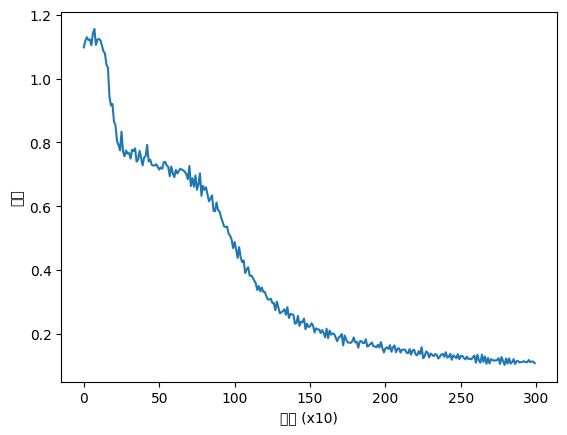

In [9]:
import sys
sys.path.append("..")
from common.optimizer import SGD
from common.trainer import Trainer
from dataset import spiral
from two_layers_net import TwoLayerNet

max_epoch = 300
batch_size = 30
hidden_size = 10
learning_rate = 1.0
x, t = spiral.load_data()
model = TwoLayerNet(input_size=2, hidden_size=hidden_size, outout_size=3)
optimizer = SGD(lr=learning_rate)

trainer = Trainer(model, optimizer)
trainer.fit(x, t, max_epoch, batch_size, eval_interval=10)
trainer.plot()

- 1.5 계산 고속화
    - 신경망의 학습화 추론에 드는 연산량은 상당함, 그래서 신경망에서는 얼마나 빠르게 계산 하느냐가 매우 중요한 주제
    - 그래서 신경 고속화에 도움되는 비트 정밀도와 GPU에 관해 간단히 설명

- 1.5.1 비트 정밀도
    - 넘파이의 부동소수점 수는 기본적으로 64비트 데이터타입 사용

In [10]:
import numpy as np
a = np.random.randn(3)
a.dtype

dtype('float64')

- 넘파이는 64비트 부동소수점 수를 표준으로 사용, 그러나 신경망 추론과 학습은 32비트 부동소수점 수로도 문제없이 수행 가능
- 32비트는 64비트의 절반이므로 메모리 관점에서는 32비트가 유리
- 신경망 계산시 데이터를 전소아는 버스 대역폭이 병목되는 현상이 종종 있음, 이런 경우에도 데이터타입이 작은 쪽이 유리, 그리고 계산속도고 32비트가 빠름

In [11]:
b = np.random.randn(3).astype(np.float32)
b.dtype

dtype('float32')

In [12]:
c = np.random.randn(3).astype("f")
c.dtype

dtype('float32')

- 신경망 추론으로 한정하면 16비트 부동소수점 수를 사용해도 인식율은 떨어지지 않지만 일반적으로 CPU와 GPU는 연산 자체를 32비트로 수행
- 16비트 부동소수점 수로 변환하더라도 계산 자체는 32비트로 진행되어 처리속도 측면에서는 변화가 없음
- 그러나 학습된 가중치를 파일에 저장할 때는 16비트 부동소수점 수가 유효
- NOTE 딥러닝이 주목받으면서 최근 GPU들은 저장과 연산 모두 16비트 반정밀도 부동소수점 수를 지원하도록 진화

- 1.5.2 GPU(쿠파이)
    - 딥러닝의 계산은 대량의 곱하기 연산으로 구성, 이 대량의 곱하기 연산 대부분은 병렬로 계산, 이 부분에서 CPU보다 GPU가 유리

In [2]:
import cupy as cp
x = cp.arange(6).reshape(2, 3).astype("f")
x

array([[0., 1., 2.],
       [3., 4., 5.]], dtype=float32)

- 정리
    - 신경망은 입렵층, 은닉층(중간층), 출력층을 지닌다
    - 완전 연결 계층에 의해 선형 변환이 이루어지고, 활성화 함수에 의해 비선형 변환이 이루어진다.
    - 완전 연결 계층이나 미니배치 처리는 행렬로 모아 한꺼번에 계산 할 수 있다.
    - 오차역전파법을 사용하여 신경망의 손실에 관한 기울기를 효율적으로 구할 수 있다.
    - 신경망이 수행하는 처리는 계산 그래프로 시각화 할 수 있으며, 순전파와 역전파를 이해하는 데 도움이 된다
    - 신경망의 구성요소들을 계층으로 모듈화 해두면 이를 조립하여 신경망을 쉽게 구성할 수 있다.
    - 신경망 고속화에는 GPU를 이용한 볍력 계산과 데이터의 비트 정밀도가 중요하다.